#**HEART DISEASE PREDICTION MODEL**

**DATASET URL:** https://archive.ics.uci.edu/dataset/45/heart+disease


###**This Prooject Aims To:**

Build a machine learning model that can predict the level of heart
disease in a patient based on various medical attributes such as age, cholesterol, blood pressure, and heart rate.

In [ ]:
!pip install ucimlrepo

## 1. Imports

In [ ]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    f1_score
)

## 2. Load the approved dataset

In [ ]:
# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

# Convert target to a 1D pandas Series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature shape: (303, 13)
Target shape: (303,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


## 3. Basic dataset exploration

In [ ]:
print("Feature columns:")
print(list(X.columns))
print("\nData types:")
print(X.dtypes)
print("\nMissing values per column:")
print(X.isna().sum())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [ ]:
# Combine for easier exploration
df = X.copy()
df["target"] = y

print("Dataset info:")
display(df.info())

print("\nSummary statistics:")
display(df.describe(include="all").T)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


None


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Notes
- missing values are present
- The target classes represent the **severity level** of heart disease.

## 4. Exploratory Data Analysis (EDA)

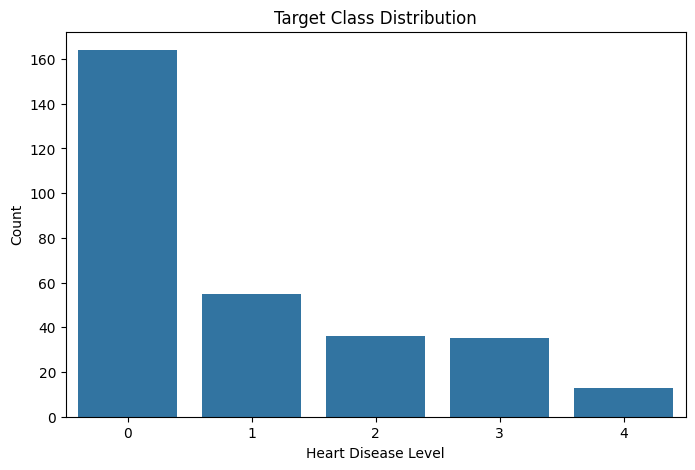

In [ ]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease Level")
plt.ylabel("Count")
plt.show()

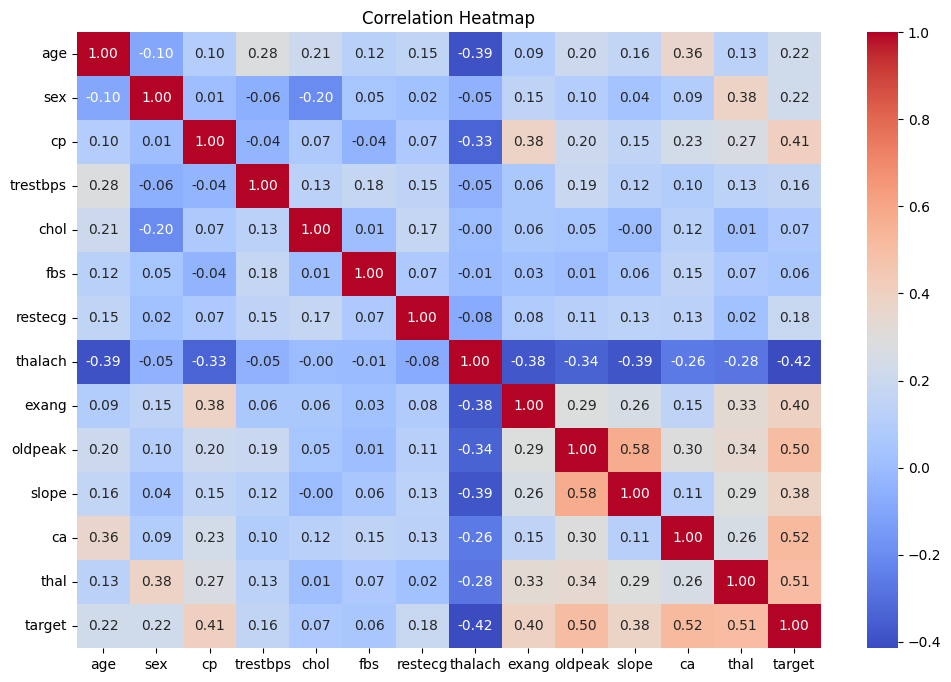

In [ ]:
# Correlation heatmap for numeric-looking columns
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

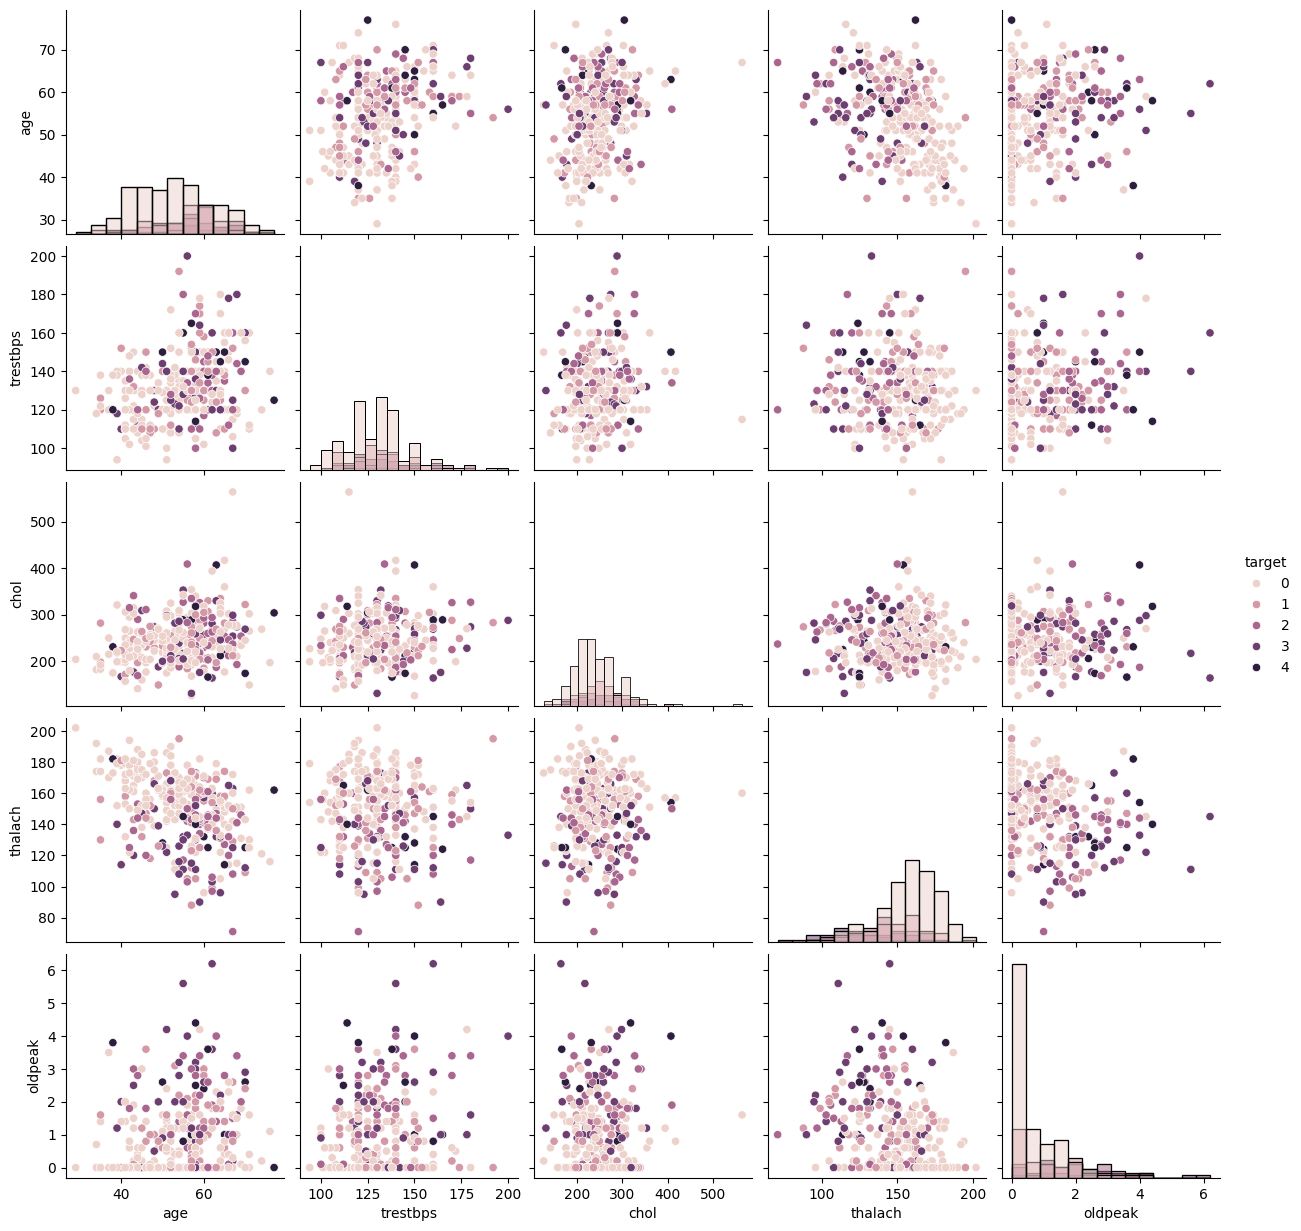

In [ ]:
# Pairplot on selected columns to keep the plot readable
selected_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
pairplot_df = df[selected_cols + ["target"]].dropna()

sns.pairplot(pairplot_df, hue="target", diag_kind="hist")
plt.show()

## 5. Preprocessing

We will use a **70/10/20 split**:
- 70% training
- 10% validation
- 20% test

### Important methodology note
A very common best practice is:
1. tune hyperparameters using cross-validation on the **training set**
2. use the **validation set** for model comparison / sanity check
3. report final performance once on the **test set**

In [ ]:
# Identify categorical and numerical columns
# These columns are categorical in the heart disease dataset
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_features = [col for col in categorical_features if col in X.columns]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [ ]:
# 70/10/20 split
# First split: 70 train, 30 temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: split temp into validation and test
# 10/30 = 1/3 for validation, 20/30 = 2/3 for test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nSplit proportions:")
total = len(X)
print(f"Train: {len(X_train)/total:.2%}")
print(f"Validation: {len(X_val)/total:.2%}")
print(f"Test: {len(X_test)/total:.2%}")

Train shape: (212, 13) (212,)
Validation shape: (30, 13) (30,)
Test shape: (61, 13) (61,)

Split proportions:
Train: 69.97%
Validation: 9.90%
Test: 20.13%


In [ ]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

## 6. Build 3 classification models

We will compare:
1. **Logistic Regression**
2. **Random Forest**
3. **Support Vector Machine (SVM)**

These provide a good mix of:
- linear baseline
- ensemble tree method
- nonlinear classifier

In [ ]:

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, multi_class="auto"))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]),

    "SVM": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(probability=True, random_state=42))
    ])
}

param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["lbfgs", "newton-cg"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 5, 10, 15],
        "classifier__min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma": ["scale", "auto"]
    }
}

## 7. Train and tune models using cross-validation

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}
cv_results_summary = []

for model_name, pipeline in models.items():
    print("=" * 80)
    print(f"Tuning: {model_name}")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_

    cv_results_summary.append({
        "Model": model_name,
        "Best CV Score (F1 Macro)": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print("Best score:", grid_search.best_score_)
    print("Best params:", grid_search.best_params_)

cv_results_df = pd.DataFrame(cv_results_summary)
display(cv_results_df)

Tuning: Logistic Regression
Best score: 0.324626316130849
Best params: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Tuning: Random Forest
Best score: 0.3539271935494846
Best params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Tuning: SVM
Best score: 0.3568912959111505
Best params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}


,Model,Best CV Score (F1 Macro),Best Parameters
0,Logistic Regression,0.324626,"{'classifier__C': 10, 'classifier__solver': 'l..."
1,Random Forest,0.353927,"{'classifier__max_depth': None, 'classifier__m..."
2,SVM,0.356891,"{'classifier__C': 10, 'classifier__gamma': 'sc..."


## 8. Evaluate on the validation set

In [ ]:

def evaluate_model(model, X_eval, y_eval, model_name, average="weighted"):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)

    acc = accuracy_score(y_eval, y_pred)
    f1 = f1_score(y_eval, y_pred, average="macro")

    classes = np.sort(np.unique(y))
    y_eval_bin = label_binarize(y_eval, classes=classes)
    auc = roc_auc_score(y_eval_bin, y_prob, multi_class="ovr", average=average)

    print(f"Model: {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Macro: {f1:.4f}")
    print(f"AUC (OvR, {average}): {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred))

    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1 Macro": f1,
        "AUC OvR": auc
    }

val_results = []
for model_name, model in best_models.items():
    print("=" * 80)
    result = evaluate_model(model, X_val, y_val, model_name)
    val_results.append(result)

val_results_df = pd.DataFrame(val_results).sort_values(by="F1 Macro", ascending=False)
display(val_results_df)

Model: Logistic Regression
Accuracy: 0.5667
F1 Macro: 0.3400
AUC (OvR, weighted): 0.7891

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.25      0.17      0.20         6
           2       0.17      0.25      0.20         4
           3       1.00      0.33      0.50         3
           4       0.00      0.00      0.00         1

    accuracy                           0.57        30
   macro avg       0.43      0.33      0.34        30
weighted avg       0.57      0.57      0.54        30

Model: Random Forest
Accuracy: 0.5667
F1 Macro: 0.2141
AUC (OvR, weighted): 0.7918

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        16
           1       0.20      0.17      0.18         6
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         3
           4       0

,Model,Accuracy,F1 Macro,AUC OvR
0,Logistic Regression,0.566667,0.340000,0.789084
1,Random Forest,0.566667,0.214141,0.791842
2,SVM,0.466667,0.173874,0.738378


## 9. Select the best model

In [ ]:
best_model_name = val_results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("Selected best model based on validation F1 Macro:")
print(best_model_name)

Selected best model based on validation F1 Macro:
Logistic Regression


## 10. Final evaluation on the test set

In [ ]:
test_results = []
for model_name, model in best_models.items():
    print("=" * 80)
    result = evaluate_model(model, X_test, y_test, model_name)
    test_results.append(result)

test_results_df = pd.DataFrame(test_results).sort_values(by="F1 Macro", ascending=False)
display(test_results_df)

Model: Logistic Regression
Accuracy: 0.6393
F1 Macro: 0.3536
AUC (OvR, weighted): 0.8579

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        33
           1       0.40      0.18      0.25        11
           2       0.12      0.14      0.13         7
           3       0.40      0.57      0.47         7
           4       0.00      0.00      0.00         3

    accuracy                           0.64        61
   macro avg       0.36      0.37      0.35        61
weighted avg       0.60      0.64      0.61        61

Model: Random Forest
Accuracy: 0.5246
F1 Macro: 0.2362
AUC (OvR, weighted): 0.7924

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.17      0.18      0.17        11
           2       0.20      0.14      0.17         7
           3       0.00      0.00      0.00         7
           4       0

,Model,Accuracy,F1 Macro,AUC OvR
0,Logistic Regression,0.639344,0.353641,0.857866
2,SVM,0.622951,0.332698,0.842427
1,Random Forest,0.524590,0.236232,0.792428


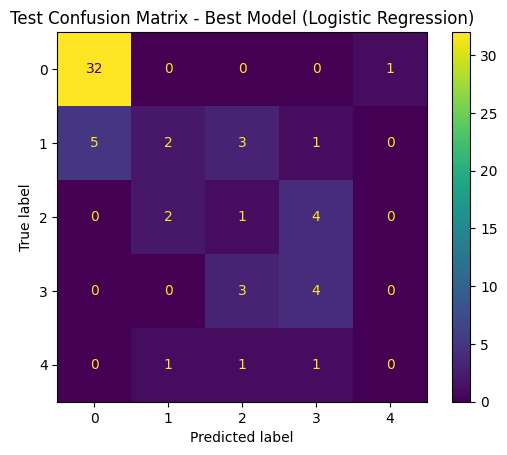

In [ ]:
# Test confusion matrix for the selected best model
y_test_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Test Confusion Matrix - Best Model ({best_model_name})")
plt.show()

## 11. ROC Curves (One-vs-Rest)

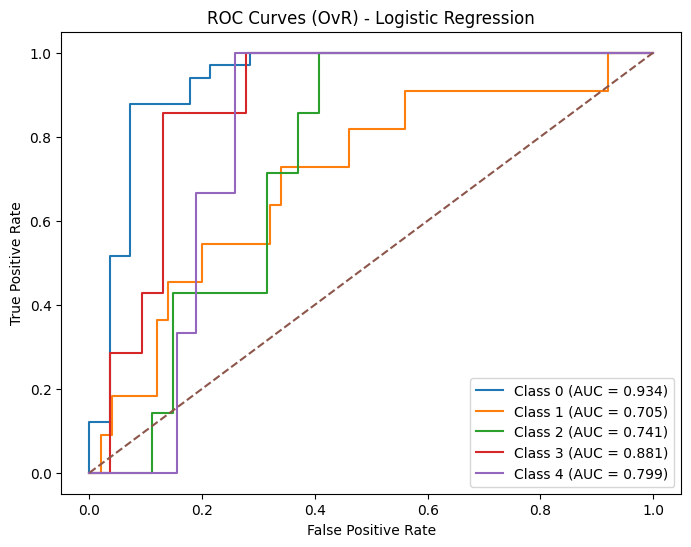

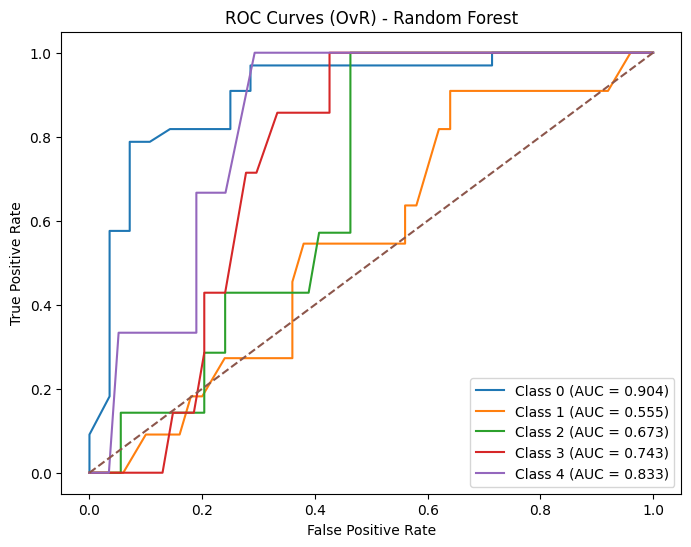

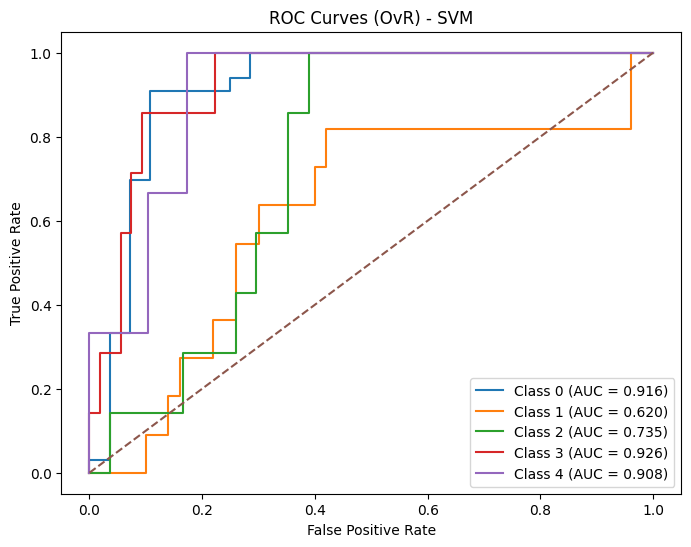

In [ ]:
classes = np.sort(np.unique(y))
y_test_bin = label_binarize(y_test, classes=classes)

for model_name, model in best_models.items():
    y_prob = model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_score = roc_auc_score((y_test == cls).astype(int), y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {auc_score:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves (OvR) - {model_name}")
    plt.legend()
    plt.show()

## 12. Final comparison table

In [ ]:
final_comparison = test_results_df.copy()
final_comparison["Selected as Best?"] = final_comparison["Model"].apply(
    lambda x: "Yes" if x == best_model_name else "No"
)
display(final_comparison)

,Model,Accuracy,F1 Macro,AUC OvR,Selected as Best?
0,Logistic Regression,0.639344,0.353641,0.857866,Yes
2,SVM,0.622951,0.332698,0.842427,No
1,Random Forest,0.524590,0.236232,0.792428,No


## 13. Conclusion

- The project used the UCI Heart Disease dataset for **multiclass classification**.
- After preprocessing and tuning, we compared **Logistic Regression, Random Forest, and SVM**.
- Based on validation and test performance, **Logistic Regression** performed best.
- The selected model achieved:
  - Accuracy: **0.639344**
  - F1 Macro: **0.353641**
  - AUC: **0.857866	**
- Therefore, **Logistic Regression** is recommended for this heart disease prediction task.